# Parquet output review -- patch_table & chip_table

Reviews the GeoParquet output of a `training/main.py` test run (`MAX_SCENES=2`) against
the [Feature Contract](../../docs/project_plan/prescient_ice_model_architecture.md#feature-contract).

Queries S3 directly via ibis's DuckDB backend (`httpfs`) so the ~12GB `patch_token` column
never has to be pulled into local memory -- only the columns each check needs are scanned.

## Connect

In [1]:
import boto3
import ibis
import matplotlib.pyplot as plt
import pandas as pd

BUCKET = "prescient-ice-data"
#PROFILE = "spk_data"
PROFILE = None
PATCH_GLOB = f"s3://{BUCKET}/training_data/ai4arctic/features/patch_table/*/*.parquet"
CHIP_GLOB = f"s3://{BUCKET}/training_data/ai4arctic/features/chip_table/*/*.parquet"

con = ibis.duckdb.connect()
con.raw_sql("INSTALL httpfs; LOAD httpfs;")
# patch_token/class_token pull ~12GB total off S3; the default http_timeout is too short
# for a full scan of those columns, so raise it (and retries) up front.
con.raw_sql("SET http_timeout=300000; SET http_retries=5;")

session = boto3.Session(profile_name=PROFILE)
creds = session.get_credentials().get_frozen_credentials()
region = session.region_name or "us-east-1"
con.raw_sql(
    f"""
    SET s3_region='{region}';
    SET s3_access_key_id='{creds.access_key}';
    SET s3_secret_access_key='{creds.secret_key}';
    SET s3_session_token='{creds.token}';
    """
)

`geometry` is excluded from the tables ibis manages: GeoParquet stores the CRS as a full
PROJJSON blob, and ibis's DuckDB type mapper doesn't yet recognize that form (raises `KeyError`
introspecting the schema). Its presence is checked separately below via a raw query that never
asks ibis to type-map the column.

In [2]:
con.raw_sql(
    f"CREATE VIEW patch_table AS SELECT * EXCLUDE (geometry) "
    f"FROM read_parquet('{PATCH_GLOB}', hive_partitioning=true)"
)
con.raw_sql(
    f"CREATE VIEW chip_table AS SELECT * EXCLUDE (geometry) "
    f"FROM read_parquet('{CHIP_GLOB}', hive_partitioning=true)"
)
patch = con.table("patch_table")
chip = con.table("chip_table")
patch.schema()

ibis.Schema {
  hh_mean               float64
  hv_mean               float64
  hh_std                float64
  hv_std                float64
  hv_hh_ratio           float64
  patch_token           array<float64>
  btemp_6.9h            float64
  btemp_6.9v            float64
  btemp_7.3h            float64
  btemp_7.3v            float64
  btemp_10.7h           float64
  btemp_10.7v           float64
  btemp_18.7h           float64
  btemp_18.7v           float64
  btemp_23.8h           float64
  btemp_23.8v           float64
  btemp_36.5h           float64
  btemp_36.5v           float64
  btemp_89.0h           float64
  btemp_89.0v           float64
  u10m_rotated          float64
  v10m_rotated          float64
  t2m                   float64
  skt                   float64
  tcwv                  float64
  tclw                  float64
  distance_to_land      float64
  ia_mean               float64
  frac_sic0             float64
  frac_sic1             float64
  frac_sic2        

## Row counts

Expect: 1024 patch rows per chip (32x32 grid, `GRID_SIZE` in `data_loader/bands.py`), one
chip_table row per chip, and (for this `MAX_SCENES=2` run) every row's `split == "train"` --
`list_all_scenes` lists `raw_train` keys before `raw_test`, so the first two scenes taken are
both train.

In [3]:
patch.group_by(["scene_id", "split"]).agg(n_rows=patch.count()).execute()

,scene_id,split,n_rows
0,S1A_EW_GRDM_1SDH_20180213T202018_20180213T2020...,train,326656
1,S1A_EW_GRDM_1SDH_20180108T184332_20180108T1844...,train,1504256


In [4]:
chip.group_by(["scene_id", "split"]).agg(n_rows=chip.count()).execute()

,scene_id,split,n_rows
0,S1A_EW_GRDM_1SDH_20180108T184332_20180108T1844...,train,1469
1,S1A_EW_GRDM_1SDH_20180213T202018_20180213T2020...,train,319


In [5]:
# patches per chip must all be exactly 1024; chip_table must have exactly one row per chip
patches_per_chip = patch.group_by("chip_id").agg(n=patch.count()).execute()
assert (patches_per_chip["n"] == 1024).all(), "found a chip without exactly 1024 patch rows"

n_unique_chips = patch.chip_id.nunique().execute()
n_chip_rows = chip.count().execute()
assert n_unique_chips == n_chip_rows, (n_unique_chips, n_chip_rows)
print("OK:", n_unique_chips, "chips, 1024 patch rows each")

OK: 1788 chips, 1024 patch rows each


## Feature-contract schema conformance

Column presence and dtype per block. `patch_token` / `class_token` are checked separately
below since their *contents* (fixed length 1024) matter more than their declared dtype.

In [6]:
EXPECTED_PATCH_COLUMNS = (
    # Block 1 -- raw HH/HV backscatter statistics
    ["hh_mean", "hv_mean", "hh_std", "hv_std", "hv_hh_ratio"]
    # Block 2 -- Clay patch token
    + ["patch_token"]
    # Block 3 -- AMSR2 brightness temperature, ascending frequency, H before V
    + [
        "btemp_6.9h",
        "btemp_6.9v",
        "btemp_7.3h",
        "btemp_7.3v",
        "btemp_10.7h",
        "btemp_10.7v",
        "btemp_18.7h",
        "btemp_18.7v",
        "btemp_23.8h",
        "btemp_23.8v",
        "btemp_36.5h",
        "btemp_36.5v",
        "btemp_89.0h",
        "btemp_89.0v",
    ]
    # Block 4 -- ERA5 surface variables, source NetCDF order
    + ["u10m_rotated", "v10m_rotated", "t2m", "skt", "tcwv", "tclw"]
    # Block 5 -- spatial/geometric context
    + ["distance_to_land", "ia_mean"]
    # labels + identifiers (not part of the feature vector itself, but written alongside it;
    # geometry excluded here -- checked separately below)
    + [f"frac_sic{k}" for k in range(11)]
    + [
        "valid_class_fraction",
        "label",
        "is_pure",
        "valid_fraction",
        "chip_id",
        "scene_id",
        "split",
    ]
)

actual_patch_columns = list(patch.columns)
missing = [c for c in EXPECTED_PATCH_COLUMNS if c not in actual_patch_columns]
extra = [c for c in actual_patch_columns if c not in EXPECTED_PATCH_COLUMNS]
assert not missing, f"patch_table missing columns: {missing}"
assert not extra, f"patch_table has unexpected columns: {extra}"

order_ok = actual_patch_columns == EXPECTED_PATCH_COLUMNS
print("patch_table column order matches contract order:", order_ok)
if not order_ok:
    print("actual:", actual_patch_columns)

patch_table column order matches contract order: True


In [7]:
EXPECTED_CHIP_COLUMNS = ["class_token", "chip_id", "scene_id", "split"]
actual_chip_columns = list(chip.columns)
assert set(actual_chip_columns) == set(EXPECTED_CHIP_COLUMNS), (
    actual_chip_columns,
    EXPECTED_CHIP_COLUMNS,
)
print("chip_table columns OK:", actual_chip_columns)

chip_table columns OK: ['class_token', 'chip_id', 'scene_id', 'split']


In [8]:
# geometry: presence + non-null, queried straight off the parquet files (not the
# geometry-excluded views above) so ibis never has to type-map the GEOMETRY column.
geom_check = con.raw_sql(
    f"SELECT count(*) AS total, count(geometry) AS non_null "
    f"FROM read_parquet('{PATCH_GLOB}', hive_partitioning=true)"
).fetchone()
assert geom_check[0] == geom_check[1], f"patch_table has null geometries: {geom_check}"
print("OK: patch_table geometry present and non-null for all", geom_check[0], "rows")

geom_check_chip = con.raw_sql(
    f"SELECT count(*) AS total, count(geometry) AS non_null "
    f"FROM read_parquet('{CHIP_GLOB}', hive_partitioning=true)"
).fetchone()
assert geom_check_chip[0] == geom_check_chip[1], (
    f"chip_table has null geometries: {geom_check_chip}"
)
print("OK: chip_table geometry present and non-null for all", geom_check_chip[0], "rows")

OK: patch_table geometry present and non-null for all 1830912 rows
OK: chip_table geometry present and non-null for all 1788 rows


## Null percentages, per scene and per chip

Same columns as before, but broken down by grain instead of flattened across the whole table --
a flat count can't tell you whether nulls are spread evenly or concentrated in one bad scene/chip.

**Per scene** (`scene_id`, one row per Sentinel-1 image): a scene with more coastline or more
out-of-swath area will legitimately show a higher `label`/`frac_sic*`/SAR-stats null percentage
than a scene mostly over open water -- that's expected geographic variation, not corruption.

**Per chip** (`chip_id`, one row per 256x256 tile): most chips should show 0% for the SAR-stats
columns (`hh_mean` etc. -- null only when a patch has zero valid, non-substituted SAR pixels) and
a coastal/edge chip may show a nonzero but partial percentage for the chart-label columns
(`label`, `frac_sic*` -- null only when a patch has zero valid chart pixels). A chip showing
100% null across *every* column (not just the label columns) would flag a chip with no usable
data at all -- worth spot-checking rather than assuming it's normal coastal/edge behaviour.

In [9]:
feature_cols = [
    c
    for c in actual_patch_columns
    if c not in ("patch_token", "geometry", "chip_id", "scene_id", "split")
]


def null_pct_aggs(cols):
    return [(patch[c].isnull().sum() * 100.0 / patch.count()).name(c) for c in cols]

In [ ]:
null_pct_by_scene = (
    patch.group_by(["scene_id", "split"]).agg(null_pct_aggs(feature_cols)).execute()
)
null_pct_by_scene

PyperclipException: 
    Pyperclip could not find a copy/paste mechanism for your system.
    For more information, please visit
    https://pyperclip.readthedocs.io/en/latest/index.html#not-implemented-error
    

In [18]:
print(null_pct_by_scene.to_csv(index=False, sep="\t"))

scene_id	split	hh_mean	hv_mean	hh_std	hv_std	hv_hh_ratio	btemp_6.9h	btemp_6.9v	btemp_7.3h	btemp_7.3v	btemp_10.7h	btemp_10.7v	btemp_18.7h	btemp_18.7v	btemp_23.8h	btemp_23.8v	btemp_36.5h	btemp_36.5v	btemp_89.0h	btemp_89.0v	u10m_rotated	v10m_rotated	t2m	skt	tcwv	tclw	distance_to_land	ia_mean	frac_sic0	frac_sic1	frac_sic2	frac_sic3	frac_sic4	frac_sic5	frac_sic6	frac_sic7	frac_sic8	frac_sic9	frac_sic10	valid_class_fraction	label	is_pure	valid_fraction
S1A_EW_GRDM_1SDH_20180213T202018_20180213T202033_020593_0233F5_596A_icechart_dmi_201802132020_CapeFarewell_RIC	train	22.92595268416928	22.92595268416928	22.92595268416928	22.92595268416928	22.92595268416928	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	78.45194945141066	78.45194945141066	78.45194945141066	78.45194945141066	78.45194945141066	78.45194945141066	78.45194945141066	78.45194945141066	78.45194945141066	78.45194945141066	78.45194945141066	0.0	78.45194945141066	0.0	0.0
S1A_EW_GRDM_1SDH_20180108T

### Per chip

1788 rows (one per chip) -- sorted by the SAR-stats null percentage descending, so a chip with
unexpectedly high nulls surfaces at the top rather than requiring a manual scan.

In [ ]:
null_pct_by_chip = (
    patch.group_by(["chip_id", "scene_id"]).agg(null_pct_aggs(feature_cols)).execute()
)
null_pct_by_chip = null_pct_by_chip.sort_values("hh_mean", ascending=False)
null_pct_by_chip

In [ ]:
print(null_pct_by_chip.to_csv(index=False, sep="\t"))

chip_id	scene_id	hh_mean	hv_mean	hh_std	hv_std	hv_hh_ratio	btemp_6.9h	btemp_6.9v	btemp_7.3h	btemp_7.3v	btemp_10.7h	btemp_10.7v	btemp_18.7h	btemp_18.7v	btemp_23.8h	btemp_23.8v	btemp_36.5h	btemp_36.5v	btemp_89.0h	btemp_89.0v	u10m_rotated	v10m_rotated	t2m	skt	tcwv	tclw	distance_to_land	ia_mean	frac_sic0	frac_sic1	frac_sic2	frac_sic3	frac_sic4	frac_sic5	frac_sic6	frac_sic7	frac_sic8	frac_sic9	frac_sic10	valid_class_fraction	label	is_pure	valid_fraction
S1A_EW_GRDM_1SDH_20180108T184332_20180108T184437_020067_022330_93EB_icechart_dmi_201801081845_CentralEast_RIC_r01024_c05120	S1A_EW_GRDM_1SDH_20180108T184332_20180108T184437_020067_022330_93EB_icechart_dmi_201801081845_CentralEast_RIC	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	100.0	100.0	100.0	100.0	100.0	100.0	100.0	100.0	100.0	100.0	100.0	0.0	100.0	0.0	0.0
S1A_EW_GRDM_1SDH_20180108T184332_20180108T184437_020067_022330_93EB_icechart_dmi_201801081845_CentralEast_RIC_r02816_c038

### Per-chip null% distribution

Histograms of the `null_pct_by_chip` columns computed above, binned in 5-point-wide buckets
(0-5, 5-10, ..., 95-100) rather than the raw per-chip table -- shows whether null% clusters near
0% (mostly-clean chips) with a long tail toward 100% (mostly-invalid edge/coastal chips), or
something less expected (e.g. a cluster in the middle). `hh_mean` stands in for the SAR-stats
null group and `label` for the chart-label null group (see the two-groups explanation above --
every column within a group is null on exactly the same rows, so one representative per group
is enough).

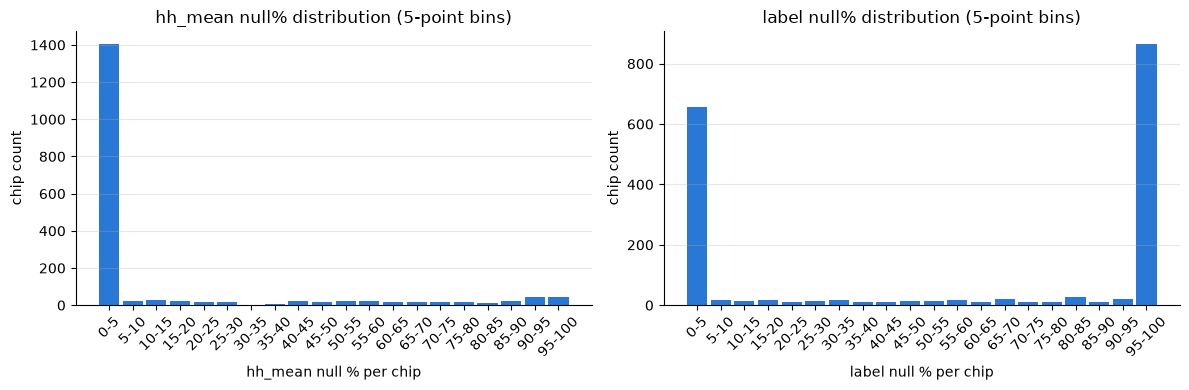

In [13]:
BIN_WIDTH = 5  # percent


def null_pct_histogram(col, ax):
    edges = list(range(0, 100 + BIN_WIDTH, BIN_WIDTH))
    binned = pd.cut(null_pct_by_chip[col], bins=edges, include_lowest=True)
    counts = binned.value_counts().sort_index()
    labels = [f"{int(iv.left)}-{int(iv.right)}" for iv in counts.index]

    ax.bar(labels, counts.to_numpy(), color="#2a78d6", width=0.85)
    ax.set_xlabel(f"{col} null % per chip")
    ax.set_ylabel("chip count")
    ax.set_title(f"{col} null% distribution ({BIN_WIDTH}-point bins)")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
null_pct_histogram("hh_mean", axes[0])
null_pct_histogram("label", axes[1])
fig.tight_layout()
plt.show()

Note: `label`, `valid_class_fraction`, and `frac_sic*` are legitimately NaN for
patches with zero valid chart pixels (`valid_class_fraction == 0`, see `label_prep.py`) --
a nonzero null percentage there is only a problem if it doesn't match the zero-valid-fraction
row count checked below.

In [ ]:
n_zero_valid_class = patch.filter(patch.valid_class_fraction == 0).count().execute()
n_null_label = patch.filter(patch.label.isnull()).count().execute()
assert n_zero_valid_class == n_null_label, (n_zero_valid_class, n_null_label)
print("OK:", n_null_label, "patches with no valid chart pixels -> NaN label, consistently")

OK: 1412316 patches with no valid chart pixels -> NaN label, consistently


## Value ranges

- `distance_to_land`: integer index 0-41 (AI4Arctic Table 7)
- `ia_mean`: Sentinel-1 EW incidence angle, ~19-47 degrees across the swath
- `valid_fraction`, `valid_class_fraction`: fractions in [0, 1]
- `label`: SIC class 0-10, or NaN (handled above)

In [ ]:
ranges = (
    patch.select(
        dtl_min=patch.distance_to_land.min(),
        dtl_max=patch.distance_to_land.max(),
        ia_min=patch.ia_mean.min(),
        ia_max=patch.ia_mean.max(),
        vf_min=patch.valid_fraction.min(),
        vf_max=patch.valid_fraction.max(),
        vcf_min=patch.valid_class_fraction.min(),
        vcf_max=patch.valid_class_fraction.max(),
        label_min=patch.label.min(),
        label_max=patch.label.max(),
    )
    .execute()
    .iloc[0]
)
print(ranges)

assert 0 <= ranges.dtl_min and ranges.dtl_max <= 41, "distance_to_land out of [0, 41]"
assert 15 <= ranges.ia_min and ranges.ia_max <= 50, "ia_mean outside plausible EW swath range"
assert 0 <= ranges.vf_min and ranges.vf_max <= 1, "valid_fraction out of [0, 1]"
assert 0 <= ranges.vcf_min and ranges.vcf_max <= 1, "valid_class_fraction out of [0, 1]"
assert 0 <= ranges.label_min and ranges.label_max <= 10, "label out of [0, 10]"
print("OK: all ranges within expected bounds")

dtl_min       0.000000
dtl_max      39.000000
ia_min       17.904741
ia_max       46.746033
vf_min        0.000000
vf_max        1.000000
vcf_min       0.000000
vcf_max       1.000000
label_min     1.000000
label_max     9.000000
Name: 0, dtype: float64
OK: all ranges within expected bounds


## `frac_sic` sums to 1

For any patch with at least one valid chart pixel, the 11 `frac_sic*` columns are an
area-fraction vector over classes 0-10 and must sum to ~1.

In [ ]:
frac_sum_expr = sum(patch[f"frac_sic{k}"] for k in range(11))
diffs = patch.filter(patch.valid_class_fraction > 0).select(diff=(frac_sum_expr - 1.0).abs())
bad = diffs.filter(diffs.diff > 1e-4).count().execute()
assert bad == 0, f"{bad} patches with frac_sic not summing to 1"
print("OK: frac_sic sums to 1 for all patches with valid chart pixels")

OK: frac_sic sums to 1 for all patches with valid chart pixels


## Vector column lengths

`patch_token` must be 1024 floats per patch (Clay's patch-token dim); `class_token` must be
1024 floats per chip. `assemble_rows` already asserts the full `(1, 1024, 32, 32)` tensor shape
before writing, so a full 1.8M-row scan of `patch_token` here would only re-check that the
parquet round-trip didn't truncate it -- not worth pulling the ~10GB column over the network
for. Sample instead; `class_token`'s table is tiny, so check it in full.

In [ ]:
SAMPLE_SIZE = 2000
token_sample = patch.select("patch_token").limit(SAMPLE_SIZE)
bad_patch_token = token_sample.filter(token_sample.patch_token.length() != 1024).count().execute()
assert bad_patch_token == 0, f"{bad_patch_token} sampled rows with patch_token length != 1024"

bad_class_token = chip.filter(chip.class_token.length() != 1024).count().execute()
assert bad_class_token == 0, f"{bad_class_token} rows with class_token length != 1024"
print(
    f"OK: patch_token fixed-length 1024 in a {SAMPLE_SIZE}-row sample; class_token OK for all rows"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

OK: patch_token fixed-length 1024 in a 2000-row sample; class_token OK for all rows


## Summary

If every assertion above ran without raising, this test run's output conforms to the
Feature Contract: correct column set/order, 1024 patches per chip, valid_fraction/label/
distance_to_land/ia_mean ranges in bounds, frac_sic normalized, and both embedding columns
fixed-length 1024.